In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_csv('kidney_disease.csv')
print(f"Shape: {df_raw.shape}  →  {df_raw.shape[0]} records, {df_raw.shape[1]} features")
pd.set_option('display.max_columns', None)
df_raw.head()

Shape: (400, 26)  →  400 records, 26 features


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
# ── 3A. Class Balance (MUST be checked early) ──────────────────────────────
print("=== Target Class Distribution ===\n", df_raw['classification'].value_counts(), "\n")

# ── 3B. Column-level quality overview ──────────────────────────────────────
def scan_data_quality(df):
    hidden_numeric, dirty_categorical = [], []
    for col in df.select_dtypes(include=['object', 'string']).columns:
        vals = df[col].dropna().unique()
        if vals.size == 0: continue
        
        if pd.to_numeric(pd.Series(vals), errors='coerce').notna().mean() > 0.5 and df[col].nunique() != len(df):
            hidden_numeric.append(col)
        elif vals.size != pd.Series(vals).astype(str).str.strip().nunique():
            dirty_categorical.append(col)
    return hidden_numeric, dirty_categorical

hidden_numeric_cols, dirty_cols_names = scan_data_quality(df_raw)

# Generate Quality Table
col_info = pd.DataFrame({
    'pandas_dtype' : df_raw.dtypes.astype(str),
    'null_count'   : df_raw.isna().sum(),
    'null_%'       : (df_raw.isna().mean() * 100).round(2),
    'n_unique'     : df_raw.nunique(),
    'sample_values': [str(df_raw[c].dropna().unique()[:3].tolist()) for c in df_raw.columns]
}).sort_values('null_%', ascending=False)

print("=== Column Quality Scan ===")
# Inline Row Styling based on row index name
display(col_info.style.apply(lambda row: 
    ['background-color: #ffe6e6'] * len(row) if row.name in hidden_numeric_cols else 
    ['background-color: #fff2cc'] * len(row) if row.name in dirty_cols_names else 
    [''] * len(row), axis=1))

if hidden_numeric_cols: print(f"• Hidden Numeric Columns (Red): {hidden_numeric_cols}")
if dirty_cols_names: print(f"• Dirty Categorical Columns (Yellow): {dirty_cols_names}")
if not hidden_numeric_cols and not dirty_cols_names:print("Everything looks fine")

=== Target Class Distribution ===
 classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64 

=== Column Quality Scan ===


,pandas_dtype,null_count,null_%,n_unique,sample_values
rbc,object,152,38.000000,2,"['normal', 'abnormal']"
rc,object,130,32.500000,49,"['5.2', '3.9', '4.6']"
wc,object,105,26.250000,92,"['7800', '6000', '7500']"
pot,float64,88,22.000000,40,"[2.5, 3.2, 4.0]"
sod,float64,87,21.750000,34,"[111.0, 142.0, 104.0]"
pcv,object,70,17.500000,44,"['44', '38', '31']"
pc,object,65,16.250000,2,"['normal', 'abnormal']"
hemo,float64,52,13.000000,115,"[15.4, 11.3, 9.6]"
su,float64,49,12.250000,6,"[0.0, 3.0, 4.0]"
sg,float64,47,11.750000,5,"[1.02, 1.01, 1.005]"


• Hidden Numeric Columns (Red): ['pcv', 'wc', 'rc']
• Dirty Categorical Columns (Yellow): ['dm', 'cad', 'classification']


In [4]:
df_clean = df_raw.copy()
print("--- Starting Automated Data Cleaning Pipeline ---")

# STEP 1: Global String Clean & Special Character Replacement
# Doing this first fixes 'ckd\t' and '?' globally in one fast pass
print("• Standardizing all text data and handling missing value placeholders...")
for col in df_clean.select_dtypes(include=['object', 'string']).columns:
    # Vectorized strip is much faster than .apply(lambda x: ...)
    df_clean[col] = df_clean[col].astype(str).str.strip()
    
    # Replace common placeholder strings with true NaNs
    df_clean[col] = df_clean[col].replace({'?': np.nan, 'nan': np.nan, 'None': np.nan})

# STEP 2: Safe Downcasting for Hidden Numeric Columns
# Since whitespace and '?' are already handled above, we just convert data types
if hidden_numeric_cols:
    for col in hidden_numeric_cols:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    print(f"✓ Converted hidden numeric columns to numeric: {hidden_numeric_cols}")
else:
    print("• No hidden numeric columns to convert.")

print("✓ Pipeline complete. All text columns stripped and standardized.")
print(f"\nTarget unique values after cleaning: {df_clean['classification'].dropna().unique()}")


--- Starting Automated Data Cleaning Pipeline ---
• Standardizing all text data and handling missing value placeholders...
✓ Converted hidden numeric columns to numeric: ['pcv', 'wc', 'rc']
✓ Pipeline complete. All text columns stripped and standardized.

Target unique values after cleaning: ['ckd' 'notckd']


In [5]:
df_clean = df_clean.drop('id', axis=1)
df_clean.shape

(400, 25)

In [6]:
%whos DataFrame

Variable   Type         Data/Info
---------------------------------
col_info   DataFrame    Shape: (26, 5)
df_clean   DataFrame    Shape: (400, 25)
df_raw     DataFrame    Shape: (400, 26)


In [7]:
df=df_clean.copy()
# ── 3A. Class Balance (MUST be checked early) ──────────────────────────────
print("=== Target Class Distribution ===\n", df['classification'].value_counts(), "\n")

# ── 3B. Column-level quality overview ──────────────────────────────────────
def scan_data_quality(df):
    hidden_numeric, dirty_categorical = [], []
    for col in df.select_dtypes(include=['object', 'string']).columns:
        vals = df[col].dropna().unique()
        if vals.size == 0: continue
        
        if pd.to_numeric(pd.Series(vals), errors='coerce').notna().mean() > 0.5 and df[col].nunique() != len(df):
            hidden_numeric.append(col)
        elif vals.size != pd.Series(vals).astype(str).str.strip().nunique():
            dirty_categorical.append(col)
    return hidden_numeric, dirty_categorical

hidden_numeric_cols, dirty_cols_names = scan_data_quality(df)

# Generate Quality Table
col_info = pd.DataFrame({
    'pandas_dtype' : df.dtypes.astype(str),
    'null_count'   : df.isna().sum(),
    'null_%'       : (df.isna().mean() * 100).round(2),
    'n_unique'     : df.nunique(),
    'sample_values': [str(df[c].dropna().unique()[:3].tolist()) for c in df.columns]
}).sort_values('null_%', ascending=False)

print("=== Column Quality Scan ===")
# Inline Row Styling based on row index name
display(col_info.style.apply(lambda row: 
    ['background-color: #ffe6e6'] * len(row) if row.name in hidden_numeric_cols else 
    ['background-color: #fff2cc'] * len(row) if row.name in dirty_cols_names else 
    [''] * len(row), axis=1))

# Print summary alerts cleanly
if hidden_numeric_cols:print(f"• Hidden Numeric Columns (Red): {hidden_numeric_cols}")
if dirty_cols_names:print(f"• Dirty Categorical Columns (Yellow): {dirty_cols_names}")
if not hidden_numeric_cols and not dirty_cols_names:print("Everything looks fine")

=== Target Class Distribution ===
 classification
ckd       250
notckd    150
Name: count, dtype: int64 

=== Column Quality Scan ===


,pandas_dtype,null_count,null_%,n_unique,sample_values
rbc,object,152,38.000000,2,"['normal', 'abnormal']"
rc,float64,131,32.750000,45,"[5.2, 3.9, 4.6]"
wc,float64,106,26.500000,89,"[7800.0, 6000.0, 7500.0]"
pot,float64,88,22.000000,40,"[2.5, 3.2, 4.0]"
sod,float64,87,21.750000,34,"[111.0, 142.0, 104.0]"
pcv,float64,71,17.750000,42,"[44.0, 38.0, 31.0]"
pc,object,65,16.250000,2,"['normal', 'abnormal']"
hemo,float64,52,13.000000,115,"[15.4, 11.3, 9.6]"
su,float64,49,12.250000,6,"[0.0, 3.0, 4.0]"
sg,float64,47,11.750000,5,"[1.02, 1.01, 1.005]"


Everything looks fine


In [8]:
print("--- Checking for Duplicate Rows ---")
duplicate_row_count = df.duplicated().sum()

if duplicate_row_count > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"✓ Removed {duplicate_row_count} duplicate rows.")
else:
    print("✓ Clean! No duplicate rows detected.")

print(f"Current Shape: {df.shape[0]} rows, {df.shape[1]} features\n")


# --- 2. Lightning-Fast Duplicate Column Investigation ---
print("--- Investigating Duplicate Columns ---")

# Vectorized transpose detection finds identical columns in C-speed, not Python loops
is_duplicate_col = df.T.duplicated(keep='first')

if is_duplicate_col.any():
    # Grab the names of the duplicate columns to be removed
    duplicate_cols = df.columns[is_duplicate_col].tolist()
    print(f"⚠ Found {len(duplicate_cols)} identical duplicate column(s): {duplicate_cols}")
    
    # Optional: Map duplicates to their original columns for clear logging
    for col in duplicate_cols:
        # Find the first column in the dataframe that matches this duplicate column perfectly
        original = df.columns[(df.T == df[col]).all(axis=1)][0]
        print(f"  • Column '{col}' is an identical twin of original column: '{original}'")
        
    print("\nℹ Action: No columns were deleted yet. Please review the twins listed above.")
else:
    print("✓ Clean! No duplicate columns detected.")

print(f"Final Shape: {df.shape[0]} rows, {df.shape[1]} features\n")

--- Checking for Duplicate Rows ---
✓ Clean! No duplicate rows detected.
Current Shape: 400 rows, 25 features

--- Investigating Duplicate Columns ---
✓ Clean! No duplicate columns detected.
Final Shape: 400 rows, 25 features



In [9]:
print("Before encoding:", df['classification'].unique())
target_mapping = {'ckd': 1, 'notckd': 0}
df['classification'] = df['classification'].map(target_mapping).astype(int)
print("After encoding: ", df['classification'].unique())
print("Class counts:\n", df['classification'].value_counts())

Before encoding: ['ckd' 'notckd']
After encoding:  [1 0]
Class counts:
 classification
1    250
0    150
Name: count, dtype: int64


In [10]:
X = df.drop(columns=['classification'])
y = df['classification']
print(f"Features matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Features matrix X: (400, 24)
Target vector  y: (400,)


# Splitting the dataset

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training Set : {X_train.shape[0]} records")
print(f"Testing Set  : {X_test.shape[0]} records")
print(f"\nClass balance in train:\n{y_train.value_counts()}")
print(f"\nClass balance in test:\n{y_test.value_counts()}")

Training Set : 320 records
Testing Set  : 80 records

Class balance in train:
classification
1    200
0    120
Name: count, dtype: int64

Class balance in test:
classification
1    50
0    30
Name: count, dtype: int64


In [12]:
# Identify quantitative and qualitative columns from training split
quan = X_train.select_dtypes(include=['number']).columns.tolist()
qual = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Quantitative columns ({len(quan)}): {quan}")
print(f"Qualitative  columns ({len(qual)}): {qual}")

Quantitative columns (14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
Qualitative  columns (10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [13]:
# ── Descriptive stats on TRAINING SPLIT only ───────────────────────────────
descriptive = pd.DataFrame(
    index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%",
           "IQR","1.5rule","Lesser","Greater","Min","Max","Skewness","Kurtosis"],
    columns=quan
)

for col in quan:
    desc = X_train[col].describe()
    descriptive.loc["Mean",    col] = X_train[col].mean()
    descriptive.loc["Median",  col] = X_train[col].median()
    descriptive.loc["Mode",    col] = X_train[col].mode()[0] if not X_train[col].mode().empty else np.nan
    descriptive.loc["Q1:25%",  col] = desc["25%"]
    descriptive.loc["Q2:50%",  col] = desc["50%"]
    descriptive.loc["Q3:75%",  col] = desc["75%"]
    descriptive.loc["Q4:100%", col] = desc["max"]
    iqr = desc["75%"] - desc["25%"]
    descriptive.loc["IQR",     col] = iqr
    descriptive.loc["1.5rule", col] = 1.5 * iqr
    descriptive.loc["Lesser",  col] = desc["25%"] - 1.5 * iqr
    descriptive.loc["Greater", col] = desc["75%"] + 1.5 * iqr
    descriptive.loc["Min",     col] = X_train[col].min()
    descriptive.loc["Max",     col] = X_train[col].max()
    descriptive.loc["Skewness",col] = X_train[col].skew()
    descriptive.loc["Kurtosis",col] = X_train[col].kurtosis()

display(descriptive)

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
Mean,51.086538,76.763754,1.017384,1.003571,0.388489,145.053191,57.445847,3.148355,137.042857,4.352459,12.518773,38.675573,8403.813559,4.716279
Median,54.0,80.0,1.02,0.0,0.0,120.5,42.0,1.2,138.0,4.3,12.6,40.0,8100.0,4.8
Mode,60.0,70.0,1.02,0.0,0.0,99.0,25.0,1.2,135.0,5.0,15.0,41.0,9200.0,5.2
Q1:25%,42.0,70.0,1.01,0.0,0.0,100.0,27.0,0.9,135.0,3.8,10.4,32.0,6300.0,3.9
Q2:50%,54.0,80.0,1.02,0.0,0.0,120.5,42.0,1.2,138.0,4.3,12.6,40.0,8100.0,4.8
Q3:75%,64.0,80.0,1.02,2.0,0.0,156.0,66.0,2.9,142.0,4.9,15.0,45.0,9800.0,5.5
Q4:100%,90.0,180.0,1.025,5.0,5.0,490.0,322.0,76.0,150.0,7.6,17.8,54.0,26400.0,6.5
IQR,22.0,10.0,0.01,2.0,0.0,56.0,39.0,2.0,7.0,1.1,4.6,13.0,3500.0,1.6
1.5rule,33.0,15.0,0.015,3.0,0.0,84.0,58.5,3.0,10.5,1.65,6.9,19.5,5250.0,2.4
Lesser,9.0,55.0,0.995,-3.0,0.0,16.0,-31.5,-2.1,124.5,2.15,3.5,12.5,1050.0,1.5


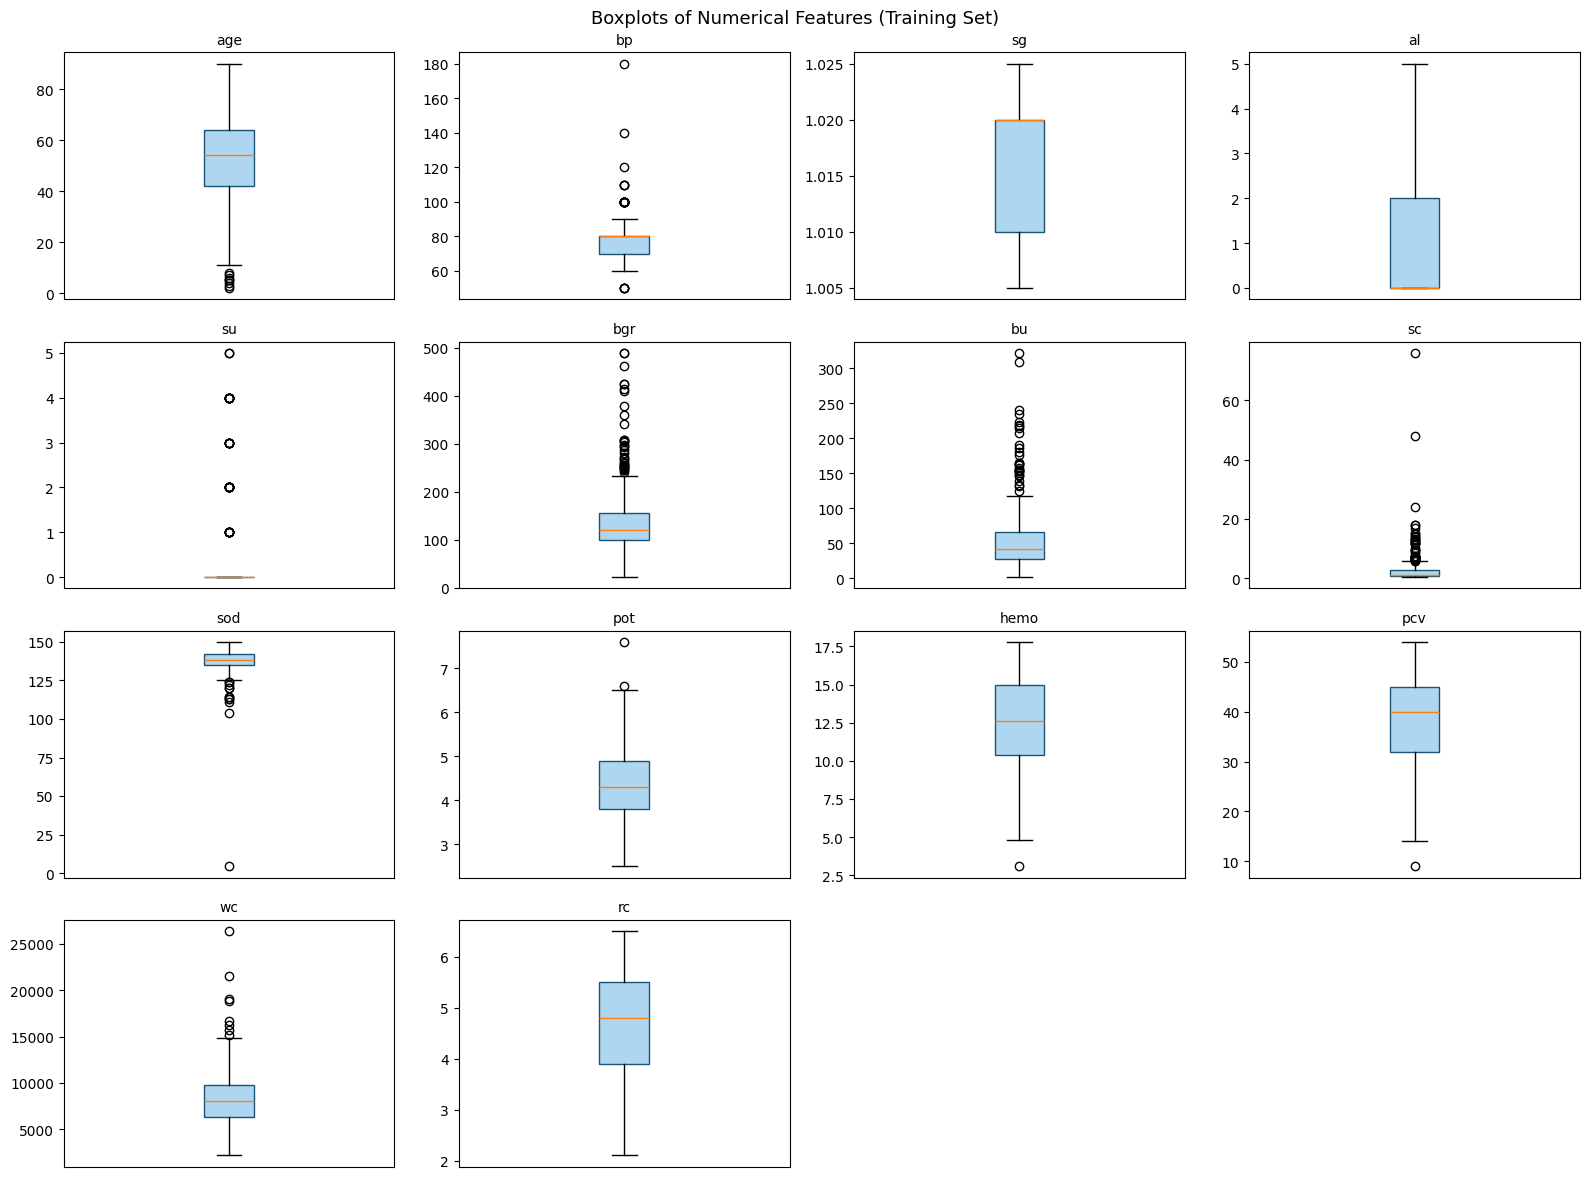

In [14]:
# ── Boxplots for visual outlier detection ──────────────────────────────────
# FIX (NEW STEP): Boxplots were missing in the original notebook
n_cols = 4
n_rows = (len(quan) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quan):
    axes[i].boxplot(X_train[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#AED6F1', color='#1A5276'))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of Numerical Features (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
def OutlierDetector(Quan, descriptive_df, data_df):
    """
    Identifies low and high outliers, returning master tables with columns organized as:
    column_name -> outlier_count -> outlier_% -> threshold -> outlier_range.
    """
    low_summary_data = []
    high_summary_data = []
    LesserOut = []
    GreaterOut = []
    total_rows = len(data_df)
    
    for columnName in Quan:
        lesser_threshold = descriptive_df.loc["Lesser", columnName]
        greater_threshold = descriptive_df.loc["Greater", columnName]
        
        # 1. Process Low Outliers
        low_vals = data_df[data_df[columnName] < lesser_threshold][columnName].tolist()
        if len(low_vals) > 0:
            LesserOut.append(columnName)
            low_min, low_max = min(low_vals), max(low_vals)
            range_str = f"[{low_min}]" if low_min == low_max else f"[{low_min} to {low_max}]"
            
            low_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(low_vals),
                "outlier_%": f"{(len(low_vals) / total_rows) * 100:.2f}%",
                "lesser_threshold": lesser_threshold,
                "outlier_range": range_str
            })
            
        # 2. Process High Outliers
        high_vals = data_df[data_df[columnName] > greater_threshold][columnName].tolist()
        if len(high_vals) > 0:
            GreaterOut.append(columnName)
            high_min, high_max = min(high_vals), max(high_vals)
            range_str = f"[{high_min}]" if high_min == high_max else f"[{high_min} to {high_max}]"
            
            high_summary_data.append({
                "column_name": columnName,
                "outlier_count": len(high_vals),
                "outlier_%": f"{(len(high_vals) / total_rows) * 100:.2f}%",
                "greater_threshold": greater_threshold,
                "outlier_range": range_str
            })
            
    df_low = pd.DataFrame(low_summary_data)
    df_high = pd.DataFrame(high_summary_data)
        
    return df_low, df_high, LesserOut, GreaterOut

In [16]:
df_low_summary, df_high_summary, lesser_outliers, greater_outliers = OutlierDetector(quan, descriptive, X_train)

print("📉 LOW OUTLIERS TABLE PROFILE:")
display(df_low_summary) 

print("\n📈 HIGH OUTLIERS TABLE PROFILE:")
display(df_high_summary)

📉 LOW OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,lesser_threshold,outlier_range
0,age,8,2.50%,9.0,[2.0 to 8.0]
1,bp,4,1.25%,55.0,[50.0]
2,sod,12,3.75%,124.5,[4.5 to 124.0]
3,hemo,1,0.31%,3.5,[3.1]
4,pcv,1,0.31%,12.5,[9.0]



📈 HIGH OUTLIERS TABLE PROFILE:


,column_name,outlier_count,outlier_%,greater_threshold,outlier_range
0,bp,27,8.44%,95.00,[100.0 to 180.0]
1,su,42,13.12%,0.00,[1.0 to 5.0]
2,bgr,33,10.31%,240.00,[241.0 to 490.0]
3,bu,29,9.06%,124.50,[125.0 to 322.0]
4,sc,42,13.12%,5.90,[6.0 to 76.0]
5,pot,2,0.62%,6.55,[6.6 to 7.6]
6,wc,8,2.50%,15050.00,[15200.0 to 26400.0]


In [17]:
def CleanExtremeOutliers(train_df, test_df, floors=None, ceilings=None):
    """
    Applies domain-driven biological thresholds to train and test sets.
    Rows are dropped from the training partition to protect model fitting.
    Test partition samples are safely clipped/capped to prevent target array mismatch.
    """
    train_clean = train_df.copy()
    test_clean  = test_df.copy()
    
    # Initialize a master row mask for training (True means keep the row)
    train_keep_mask = pd.Series(True, index=train_clean.index)

    # 1. Evaluate Low Floors
    if floors:
        for col, floor_val in floors.items():
            if col in train_clean.columns:
                # Identify training rows that break the boundary
                violation_mask = (train_clean[col] < floor_val) & train_clean[col].notna()
                if violation_mask.any():
                    print(f"[TRAIN BOUNDARY] {col}: Flagged {violation_mask.sum()} rows below biological floor ({floor_val})")
                    train_keep_mask &= ~violation_mask
                
                # Safe clipping for evaluation pipeline
                test_clean[col] = test_clean[col].clip(lower=floor_val)

    # 2. Evaluate High Ceilings
    if ceilings:
        for col, ceiling_val in ceilings.items():
            if col in train_clean.columns:
                # Identify training rows that break the boundary
                violation_mask = (train_clean[col] > ceiling_val) & train_clean[col].notna()
                if violation_mask.any():
                    print(f"[TRAIN BOUNDARY] {col}: Flagged {violation_mask.sum()} rows above biological ceiling ({ceiling_val})")
                    train_keep_mask &= ~violation_mask
                
                # Safe clipping for evaluation pipeline
                test_clean[col] = test_clean[col].clip(upper=ceiling_val)

    # Execute dropping logic on training in one fast step
    initial_rows = len(train_clean)
    train_clean = train_clean[train_keep_mask]
    
    print(f"\n✓ Sanitization Complete. Train set size: {initial_rows} ➔ {len(train_clean)} rows.")
    print(f"✓ Test set size preserved: {len(test_clean)} rows (Outliers safely capped).")
    
    return train_clean, test_clean

In [18]:
print(f"Low_floor columns: {df_low_summary['column_name'].unique()}")
print(f"Hihg_ceilings columns: {df_high_summary['column_name'].unique()}")

Low_floor columns: ['age' 'bp' 'sod' 'hemo' 'pcv']
Hihg_ceilings columns: ['bp' 'su' 'bgr' 'bu' 'sc' 'pot' 'wc']


In [19]:
# Updated parameters matching only active outlier columns
low_floors = {"age": 0.0, "bp": 40.0, "sod": 100.0, "hemo": 2.5, "pcv": 8.0}

high_ceilings = {"bp": 200.0, "su": 6.0, "bgr": 600.0, "bu": 450.0,
                 "sc": 20.0, "pot": 10.0, "wc": 30000.0}

# Execution
X_train, X_test = CleanExtremeOutliers(X_train, X_test, floors=low_floors, ceilings=high_ceilings)

# Re-align target labels
y_train = y_train.loc[X_train.index]

print(f"\nAligned y_train size: {y_train.shape}")
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

[TRAIN BOUNDARY] sod: Flagged 1 rows below biological floor (100.0)
[TRAIN BOUNDARY] sc: Flagged 3 rows above biological ceiling (20.0)

✓ Sanitization Complete. Train set size: 320 ➔ 317 rows.
✓ Test set size preserved: 80 rows (Outliers safely capped).

Aligned y_train size: (317,)
X_train shape: (317, 24) | X_test shape: (80, 24)


Class distribution in training set:
classification
1    197
0    120
Name: count, dtype: int64

Imbalance ratio: 1.64:1


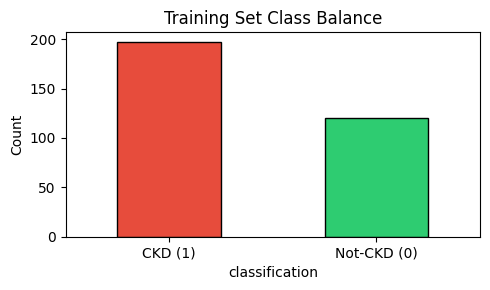


Strategy: Use class_weight='balanced' in classifiers that support it.


In [20]:
print("Class distribution in training set:")
print(y_train.value_counts())
print(f"\nImbalance ratio: {y_train.value_counts().iloc[0] / y_train.value_counts().iloc[1]:.2f}:1")

fig, ax = plt.subplots(figsize=(5, 3))
y_train.value_counts().plot(kind='bar', ax=ax, color=['#E74C3C', '#2ECC71'], edgecolor='black')
ax.set_xticklabels(['CKD (1)', 'Not-CKD (0)'], rotation=0)
ax.set_title('Training Set Class Balance')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print("\nStrategy: Use class_weight='balanced' in classifiers that support it.")

In [22]:
def audit_missing_data(dataframe):
    null_count = dataframe.isna().sum()
    null_pct = (dataframe.isna().mean() * 100).round(2)
    
    bins = [-1, 0, 5, 15, 30, 50, 100]
    labels = ['✅ COMPLETE', '🟢 VERY LOW', '🟡 LOW', '🟠 MODERATE', '🔴 HIGH', '❌ DROP']
    tiers = pd.cut(null_pct, bins=bins, labels=labels, right=True).astype(str)
    
    return pd.DataFrame({
        'Missing Count': null_count, 'Missing %': null_pct,
        'dtype': dataframe.dtypes.astype(str), 'Tier': tiers
    }).sort_values('Missing %', ascending=False)

def extract_imputation_lists(dataframe, audit_df):
    num_cols = dataframe.select_dtypes(include=['number']).columns
    cat_cols = dataframe.select_dtypes(exclude=['number']).columns
    pct = audit_df['Missing %']
    
    # Using strict tier boundaries to ensure 0% missing data is separated from 1-5%
    return {
        "drop_col":       audit_df[pct > 50].index.tolist(),
        "high_num":       audit_df[(pct > 30) & (pct <= 50) & audit_df.index.isin(num_cols)].index.tolist(),
        "high_cate":      audit_df[(pct > 30) & (pct <= 50) & audit_df.index.isin(cat_cols)].index.tolist(),
        "mid_num":        audit_df[(pct > 15) & (pct <= 30) & audit_df.index.isin(num_cols)].index.tolist(),
        "mid_cate":       audit_df[(pct > 15) & (pct <= 30) & audit_df.index.isin(cat_cols)].index.tolist(),
        "low_num":        audit_df[(pct > 5)  & (pct <= 15) & audit_df.index.isin(num_cols)].index.tolist(),
        "low_cate":       audit_df[(pct > 5)  & (pct <= 15) & audit_df.index.isin(cat_cols)].index.tolist(),
        "very_low_num":   audit_df[(pct > 0)  & (pct <= 5)  & audit_df.index.isin(num_cols)].index.tolist(),
        "very_low_cate":  audit_df[(pct > 0)  & (pct <= 5)  & audit_df.index.isin(cat_cols)].index.tolist(),
        "complete_num":   audit_df[(pct == 0) & audit_df.index.isin(num_cols)].index.tolist(),
        "complete_cate":  audit_df[(pct == 0) & audit_df.index.isin(cat_cols)].index.tolist(),
    }

In [23]:
# 1. Generate the Audit Table
training_audit = audit_missing_data(X_train)

print('📊 Training Split Automated Missing Value Audit:')
print('=' * 65)
display(training_audit)
print('=' * 65)

# 2. Extract and Unpack Feature Lists
imputation_configs = extract_imputation_lists(X_train, training_audit)
globals().update(imputation_configs)

print('\n🎯 Extracted Feature Tiers Ready for Downstream Transformers:')
for key, feature_list in imputation_configs.items():
    print(f" 🔹 {key:14} (Count: {len(feature_list)}): {feature_list}")

📊 Training Split Automated Missing Value Audit:


,Missing Count,Missing %,dtype,Tier
rbc,123,38.80,object,🔴 HIGH
rc,103,32.49,float64,🔴 HIGH
wc,82,25.87,float64,🟠 MODERATE
pot,74,23.34,float64,🟠 MODERATE
sod,74,23.34,float64,🟠 MODERATE
pcv,57,17.98,float64,🟠 MODERATE
pc,52,16.40,object,🟠 MODERATE
hemo,42,13.25,float64,🟡 LOW
su,40,12.62,float64,🟡 LOW
sg,39,12.30,float64,🟡 LOW



🎯 Extracted Feature Tiers Ready for Downstream Transformers:
 🔹 drop_col       (Count: 0): []
 🔹 high_num       (Count: 1): ['rc']
 🔹 high_cate      (Count: 1): ['rbc']
 🔹 mid_num        (Count: 4): ['wc', 'pot', 'sod', 'pcv']
 🔹 mid_cate       (Count: 1): ['pc']
 🔹 low_num        (Count: 7): ['hemo', 'su', 'sg', 'al', 'bgr', 'bu', 'sc']
 🔹 low_cate       (Count: 0): []
 🔹 very_low_num   (Count: 2): ['bp', 'age']
 🔹 very_low_cate  (Count: 8): ['pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
 🔹 complete_num   (Count: 0): []
 🔹 complete_cate  (Count: 0): []


## imputation

In [24]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder

# Create clean copies of your data
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

# ==========================================
# 1. DROP STRATEGY (>50% Missing)
# ==========================================
X_train_clean.drop(columns=drop_col, errors='ignore', inplace=True)
X_test_clean.drop(columns=drop_col, errors='ignore', inplace=True)


# ==========================================
# 2. NUMERICAL IMPUTATION
# ==========================================

# --- Very Low Numerical: Median ---
for col in very_low_num:
    median_val = X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(median_val)
    X_test_clean[col]  = X_test_clean[col].fillna(median_val)

# --- Low Numerical: Mean or Median based on Skewness ---
for col in low_num:
    skew_val = X_train_clean[col].skew()
    fill_val = X_train_clean[col].mean() if abs(skew_val) <= 0.5 else X_train_clean[col].median()
    X_train_clean[col] = X_train_clean[col].fillna(fill_val)
    X_test_clean[col]  = X_test_clean[col].fillna(fill_val)

# --- Mid Numerical: MICE ---
if mid_num:
    mice = IterativeImputer(max_iter=10, random_state=42)
    X_train_clean[mid_num] = mice.fit_transform(X_train_clean[mid_num])
    X_test_clean[mid_num]  = mice.transform(X_test_clean[mid_num])

# --- High Numerical: KNN ---
if high_num:
    knn_num = KNNImputer(n_neighbors=5)
    X_train_clean[high_num] = knn_num.fit_transform(X_train_clean[high_num])
    X_test_clean[high_num]  = knn_num.transform(X_test_clean[high_num])


# ==========================================
# 3. CATEGORICAL IMPUTATION
# ==========================================

# --- Simple Categorical (Very Low, Low, Mid): Fill with Mode ---
simple_cat_cols = very_low_cate + low_cate + mid_cate

for col in simple_cat_cols:
    if col in X_train_clean.columns:
        # Calculate the text mode value from your training split
        mode_val = X_train_clean[col].mode()[0]
        X_train_clean[col] = X_train_clean[col].fillna(mode_val)
        X_test_clean[col]  = X_test_clean[col].fillna(mode_val)

# --- High Categorical: KNN (Encoded) + Flag ---
if high_cate:
    # A. Add the tracking missingness flag first (0 = present, 1 = missing)
    for col in high_cate:
        X_train_clean[f'{col}_is_missing'] = X_train_clean[col].isna().astype(int)
        X_test_clean[f'{col}_is_missing'] = X_test_clean[col].isna().astype(int)
        
    # B. Use OrdinalEncoder to convert text to numbers, keeping true NaNs intact
    # encoded_missing_value=-1 allows the encoder to ignore NaNs during the step
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=np.nan)
    
    X_train_clean[high_cate] = encoder.fit_transform(X_train_clean[high_cate])
    X_test_clean[high_cate]  = encoder.transform(X_test_clean[high_cate])
    
    # C. Run KNNImputer over the numerical representation of your high categorical columns
    knn_cat = KNNImputer(n_neighbors=5)
    
    X_train_clean[high_cate] = knn_cat.fit_transform(X_train_clean[high_cate])
    X_test_clean[high_cate]  = knn_cat.transform(X_test_clean[high_cate])
    
    # D. Round the KNN decimal predictions back to whole numbers and decode to text
    X_train_clean[high_cate] = np.round(X_train_clean[high_cate])
    X_test_clean[high_cate]  = np.round(X_test_clean[high_cate])
    
    X_train_clean[high_cate] = encoder.inverse_transform(X_train_clean[high_cate])
    X_test_clean[high_cate]  = encoder.inverse_transform(X_test_clean[high_cate])


# ==========================================
# 4. SANITY CHECK VERIFICATION
# ==========================================
print("🚨 Verification Summary:")
print("-" * 30)
print("Missing values in Train data:", X_train_clean.isna().sum().sum())
print("Missing values in Test data :", X_test_clean.isna().sum().sum())
print("Newly added indicator flags:", [c for c in X_train_clean.columns if '_is_missing' in c])

🚨 Verification Summary:
------------------------------
Missing values in Train data: 0
Missing values in Test data : 0
Newly added indicator flags: ['rbc_is_missing']


In [25]:
# 1. Generate the Audit Table
training_audit = audit_missing_data(X_train_clean)

print('📊 Training Split Automated Missing Value Audit:')
print('=' * 65)
display(training_audit)
print('=' * 65)

# 2. Extract and Unpack Feature Lists
imputation_configs = extract_imputation_lists(X_train, training_audit)
globals().update(imputation_configs)

print('\n🎯 Extracted Feature Tiers Ready for Downstream Transformers:')
for key, feature_list in imputation_configs.items():
    print(f" 🔹 {key:14} (Count: {len(feature_list)}): {feature_list}")

📊 Training Split Automated Missing Value Audit:


,Missing Count,Missing %,dtype,Tier
age,0,0.0,float64,✅ COMPLETE
bp,0,0.0,float64,✅ COMPLETE
sg,0,0.0,float64,✅ COMPLETE
al,0,0.0,float64,✅ COMPLETE
su,0,0.0,float64,✅ COMPLETE
rbc,0,0.0,object,✅ COMPLETE
pc,0,0.0,object,✅ COMPLETE
pcc,0,0.0,object,✅ COMPLETE
ba,0,0.0,object,✅ COMPLETE
bgr,0,0.0,float64,✅ COMPLETE



🎯 Extracted Feature Tiers Ready for Downstream Transformers:
 🔹 drop_col       (Count: 0): []
 🔹 high_num       (Count: 0): []
 🔹 high_cate      (Count: 0): []
 🔹 mid_num        (Count: 0): []
 🔹 mid_cate       (Count: 0): []
 🔹 low_num        (Count: 0): []
 🔹 low_cate       (Count: 0): []
 🔹 very_low_num   (Count: 0): []
 🔹 very_low_cate  (Count: 0): []
 🔹 complete_num   (Count: 14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']
 🔹 complete_cate  (Count: 10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [26]:
X_train_clean

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,rbc_is_missing
108,45.0,80.0,1.01500,0.0,0.0,normal,abnormal,notpresent,notpresent,107.0,15.0,1.0,141.0,4.2,11.800000,37.000000,10200.0,4.200000,no,no,no,good,no,no,1
210,59.0,100.0,1.01500,4.0,2.0,normal,normal,notpresent,notpresent,255.0,132.0,12.8,135.0,5.7,7.300000,20.000000,9800.0,3.900000,yes,yes,yes,good,no,yes,0
137,45.0,60.0,1.01000,2.0,0.0,normal,abnormal,present,notpresent,268.0,86.0,4.0,134.0,5.1,10.000000,29.000000,9200.0,4.721495,yes,yes,no,good,no,no,0
246,48.0,110.0,1.01500,3.0,0.0,abnormal,normal,present,notpresent,106.0,215.0,15.2,120.0,5.7,8.600000,26.000000,5000.0,2.500000,yes,no,yes,good,no,yes,0
175,60.0,50.0,1.01000,0.0,0.0,normal,normal,notpresent,notpresent,261.0,58.0,2.2,113.0,3.0,12.525091,25.237737,4200.0,3.400000,yes,no,no,good,no,no,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,47.0,100.0,1.01000,0.0,0.0,normal,normal,notpresent,notpresent,204.0,29.0,1.0,139.0,4.2,9.700000,33.000000,9200.0,4.500000,yes,no,no,good,no,yes,1
346,33.0,60.0,1.01741,0.0,0.0,normal,normal,notpresent,notpresent,130.0,41.0,0.9,141.0,4.4,15.500000,52.000000,4300.0,5.800000,no,no,no,good,no,no,0
20,61.0,80.0,1.01500,2.0,0.0,abnormal,abnormal,notpresent,notpresent,173.0,148.0,3.9,135.0,5.2,7.700000,24.000000,9200.0,3.200000,yes,yes,yes,poor,yes,yes,0
144,60.0,90.0,1.01000,2.0,0.0,abnormal,normal,notpresent,notpresent,105.0,53.0,2.3,136.0,5.2,11.100000,33.000000,10500.0,4.100000,no,no,no,good,no,no,0


In [27]:
from sklearn.preprocessing import OneHotEncoder

# ==========================================
# 0. INITIALIZATION & MEMORY PROTECTION
# ==========================================
# Always pull fresh copies of data from your clean imputation baseline variables
# This guarantees you can rerun this cell cleanly out-of-order without memory crashes
X_train_encoded = X_train_clean.copy()
X_test_encoded  = X_test_clean.copy()

# ==========================================
# 1. DYNAMIC CATEGORICAL SCANNING
# ==========================================
# Automatically find all text/category headers while leaving the numeric _is_missing flags intact
text_columns = [
    col for col in X_train_encoded.select_dtypes(include=['object', 'category']).columns 
    if not col.endswith('_is_missing')
]

# Separate features into binary and multi-class based purely on training profile profiles
binary_cols = [col for col in text_columns if X_train_encoded[col].nunique() <= 2]
multiclass_cols = [col for col in text_columns if X_train_encoded[col].nunique() > 2]

print("=== Encoding Feature Categorization ===")
print(f"🔹 Binary features mapped ({len(binary_cols)}): {binary_cols}")
print(f"🔹 Multi-class features mapped ({len(multiclass_cols)}): {multiclass_cols}\n")


# ==========================================
# 2. BINARY FEATURE TRANSFORMATION (0 or 1)
# ==========================================
if binary_cols:
    for col in binary_cols:
        # Cast to standard string arrays and read the unique elements present in the training set
        train_categories = X_train_encoded[col].astype(str).unique()
        
        # Build an explicit, clean 0/1 integer index mapping dictionary layout
        binary_map = {category_name: index for index, category_name in enumerate(train_categories[:2])}
        
        # Apply mapping across columns simultaneously via native vectorized math.
        # Unknown values in test split are safely caught using .fillna(0) to prevent rogue negative coordinates
        X_train_encoded[col] = X_train_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)
        X_test_encoded[col]  = X_test_encoded[col].astype(str).map(binary_map).fillna(0).astype(int)


# ==========================================
# 3. MULTI-CLASS FEATURE TRANSFORMATION (OHE)
# ==========================================
if multiclass_cols:
    # Initialize encoder. handle_unknown='ignore' ensures any brand-new unseen test categories are silently dropped
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=int)
    
    # Fit on training data and transform arrays via C-speed matrix operations
    train_ohe_array = ohe.fit_transform(X_train_encoded[multiclass_cols].astype(str))
    test_ohe_array  = ohe.transform(X_test_encoded[multiclass_cols].astype(str))
    
    # Generate human-readable new feature names (e.g., 'feature_category')
    new_column_names = ohe.get_feature_names_out(multiclass_cols)
    
    # Package matrices back into beautifully structured dataframes, keeping original index numbers aligned
    train_ohe_df = pd.DataFrame(train_ohe_array, columns=new_column_names, index=X_train_encoded.index)
    test_ohe_df  = pd.DataFrame(test_ohe_array,  columns=new_column_names, index=X_test_encoded.index)
    
    # Clean drop old original text string variables and append the newly created binary dummy columns
    X_train_encoded = pd.concat([X_train_encoded.drop(columns=multiclass_cols), train_ohe_df], axis=1)
    X_test_encoded  = pd.concat([X_test_encoded.drop(columns=multiclass_cols),  test_ohe_df],  axis=1)


# ==========================================
# 4. FINAL ENCODING VERIFICATION DIAGNOSTICS
# ==========================================
print("🚨 Stage 3 Encoding Verification Summary:")
print("-" * 45)

train_leftover_text = X_train_encoded.select_dtypes(include=['object', 'category']).columns.tolist()
test_leftover_text  = X_test_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"✓ Leftover text/category columns in Train split: {train_leftover_text}")
print(f"✓ Leftover text/category columns in Test split : {test_leftover_text}")
print(f"✓ Operational Matrix Dimensions -> Train shape : {X_train_encoded.shape}")
print(f"✓ Operational Matrix Dimensions -> Test shape  : {X_test_encoded.shape}")

=== Encoding Feature Categorization ===
🔹 Binary features mapped (10): ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
🔹 Multi-class features mapped (0): []

🚨 Stage 3 Encoding Verification Summary:
---------------------------------------------
✓ Leftover text/category columns in Train split: []
✓ Leftover text/category columns in Test split : []
✓ Operational Matrix Dimensions -> Train shape : (317, 25)
✓ Operational Matrix Dimensions -> Test shape  : (80, 25)


In [28]:
X_train_encoded

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,rbc_is_missing
108,45.0,80.0,1.01500,0.0,0.0,0,0,0,0,107.0,15.0,1.0,141.0,4.2,11.800000,37.000000,10200.0,4.200000,0,0,0,0,0,0,1
210,59.0,100.0,1.01500,4.0,2.0,0,1,0,0,255.0,132.0,12.8,135.0,5.7,7.300000,20.000000,9800.0,3.900000,1,1,1,0,0,1,0
137,45.0,60.0,1.01000,2.0,0.0,0,0,1,0,268.0,86.0,4.0,134.0,5.1,10.000000,29.000000,9200.0,4.721495,1,1,0,0,0,0,0
246,48.0,110.0,1.01500,3.0,0.0,1,1,1,0,106.0,215.0,15.2,120.0,5.7,8.600000,26.000000,5000.0,2.500000,1,0,1,0,0,1,0
175,60.0,50.0,1.01000,0.0,0.0,0,1,0,0,261.0,58.0,2.2,113.0,3.0,12.525091,25.237737,4200.0,3.400000,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,47.0,100.0,1.01000,0.0,0.0,0,1,0,0,204.0,29.0,1.0,139.0,4.2,9.700000,33.000000,9200.0,4.500000,1,0,0,0,0,1,1
346,33.0,60.0,1.01741,0.0,0.0,0,1,0,0,130.0,41.0,0.9,141.0,4.4,15.500000,52.000000,4300.0,5.800000,0,0,0,0,0,0,0
20,61.0,80.0,1.01500,2.0,0.0,1,0,0,0,173.0,148.0,3.9,135.0,5.2,7.700000,24.000000,9200.0,3.200000,1,1,1,1,1,1,0
144,60.0,90.0,1.01000,2.0,0.0,1,1,0,0,105.0,53.0,2.3,136.0,5.2,11.100000,33.000000,10500.0,4.100000,0,0,0,0,0,0,0


In [29]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler instance
scaler = StandardScaler()

# 2. FIT & TRANSFORM: Training split conversion
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_encoded), 
    columns=X_train_encoded.columns, 
    index=X_train_encoded.index
)

# 3. TRANSFORM ONLY: Test split conversion (Prevents Data Leakage)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_encoded), 
    columns=X_test_encoded.columns, 
    index=X_test_encoded.index
)

# ==========================================
# 4. BULLETPROOF POPULATION SCALE VERIFICATION
# ==========================================
print("🚨 Stage 4 Preprocessing Complete:")
print("-" * 40)

# Using np.mean and np.std calculates population statistics matching Scikit-Learn exactly
first_col_array = X_train_scaled.iloc[:, 0].to_numpy()
print("Population Mean of first feature (Matches Sklearn) :", round(np.mean(first_col_array), 4))
print("Population Std of first feature  (Exactly 1.0)     :", round(np.std(first_col_array), 4))
print(f"Final Data Shapes -> Train Matrix: {X_train_scaled.shape} | Test Matrix: {X_test_scaled.shape}")

🚨 Stage 4 Preprocessing Complete:
----------------------------------------
Population Mean of first feature (Matches Sklearn) : 0.0
Population Std of first feature  (Exactly 1.0)     : 1.0
Final Data Shapes -> Train Matrix: (317, 25) | Test Matrix: (80, 25)


In [30]:
X_train_scaled

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,rbc_is_missing
108,-0.355574,0.221825,-4.565099e-01,-0.683033,-0.349513,-0.357930,-2.007921,-0.37455,-0.2595,-0.490939,-0.860391,-0.500235,0.555572,-0.237654,-2.615514e-01,-0.178261,0.649134,-6.235856e-01,-0.754524,-0.683807,-0.286201,-0.488141,-0.473221,-0.427593,1.255880
210,0.471057,1.656898,-4.565099e-01,2.399125,1.702256,-0.357930,0.498028,-0.37455,-0.2595,1.570446,1.582149,3.160128,-0.432647,2.012331,-1.884770e+00,-2.227500,0.499169,-9.823150e-01,1.325338,1.462400,3.494043,-0.488141,-0.473221,2.338672,-0.796254
137,-0.355574,-1.213247,-1.403598e+00,0.858046,-0.349513,-0.357930,-2.007921,2.66987,-0.2595,1.751513,0.621834,0.430366,-0.597350,1.112337,-9.108388e-01,-1.142609,0.274220,1.062052e-15,1.325338,1.462400,-0.286201,-0.488141,-0.473221,-0.427593,-0.796254
246,-0.178439,2.374434,-4.565099e-01,1.628585,-0.349513,2.793842,0.498028,2.66987,-0.2595,-0.504867,3.314890,3.904609,-2.903195,2.012331,-1.415840e+00,-1.504239,-1.300419,-2.656385e+00,1.325338,-0.683807,3.494043,-0.488141,-0.473221,2.338672,-0.796254
175,0.530102,-1.930784,-1.403598e+00,-0.683033,-0.349513,-0.357930,0.498028,-0.37455,-0.2595,1.654015,0.037294,-0.127994,-4.056117,-2.037643,6.407590e-16,-1.596125,-1.600350,-1.580197e+00,1.325338,-0.683807,-0.286201,-0.488141,-0.473221,-0.427593,1.255880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,-0.237484,1.656898,-1.403598e+00,-0.683033,-0.349513,-0.357930,0.498028,-0.37455,-0.2595,0.860104,-0.568121,-0.500235,0.226166,-0.237654,-1.019053e+00,-0.660435,0.274220,-2.648563e-01,1.325338,-0.683807,-0.286201,-0.488141,-0.473221,2.338672,1.255880
346,-1.064115,-1.213247,4.205914e-14,-0.683033,-0.349513,-0.357930,0.498028,-0.37455,-0.2595,-0.170588,-0.317605,-0.531255,0.555572,0.062344,1.073095e+00,1.629890,-1.562858,1.289638e+00,-0.754524,-0.683807,-0.286201,-0.488141,-0.473221,-0.427593,-0.796254
20,0.589147,0.221825,-4.565099e-01,0.858046,-0.349513,2.793842,-2.007921,-0.37455,-0.2595,0.428327,1.916171,0.399346,-0.432647,1.262336,-1.740484e+00,-1.745326,0.274220,-1.819350e+00,1.325338,1.462400,3.494043,2.048590,2.113177,2.338672,-0.796254
144,0.530102,0.939361,-1.403598e+00,0.858046,-0.349513,2.793842,0.498028,-0.37455,-0.2595,-0.518795,-0.067088,-0.096974,-0.267944,1.262336,-5.140521e-01,-0.660435,0.761609,-7.431621e-01,-0.754524,-0.683807,-0.286201,-0.488141,-0.473221,-0.427593,-0.796254


In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)
y_dummy_pred = dummy.predict(X_test_scaled)

print("=== Baseline (DummyClassifier — Majority Class) ===")
print(f"Accuracy : {accuracy_score(y_test, y_dummy_pred)*100:.2f}%")
print(f"F1-Score : {f1_score(y_test, y_dummy_pred, zero_division=0)*100:.2f}%")
print("\nAny real model MUST score better than this baseline.")

=== Baseline (DummyClassifier — Majority Class) ===
Accuracy : 62.50%
F1-Score : 76.92%

Any real model MUST score better than this baseline.


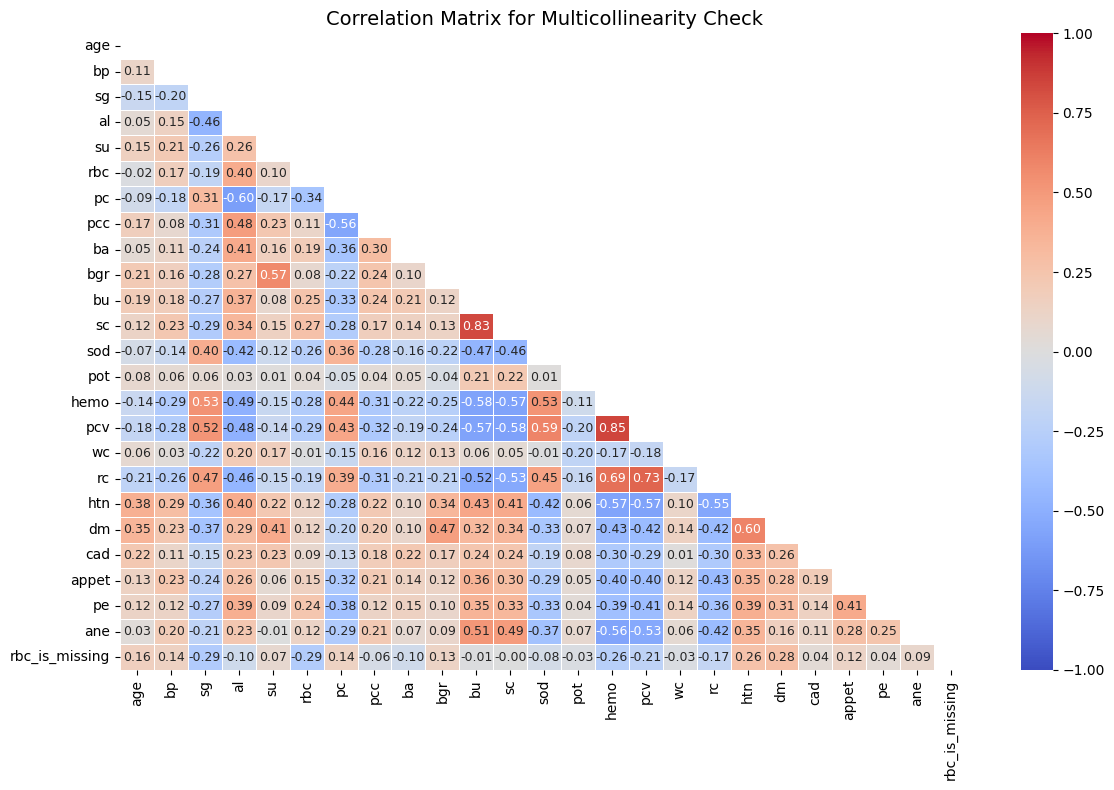


--- Variance Inflation Factor (VIF) Scores ---
           Feature       VIF
0              pcv  5.134712
1             hemo  4.685318
2               bu  3.910491
3               sc  3.842667
4               rc  2.565562
5               al  2.435878
6              htn  2.424666
7               pc  2.213192
8               dm  2.089528
9               sg  1.883530
10             sod  1.857543
11             ane  1.781166
12              su  1.778527
13             pcc  1.775285
14             bgr  1.774878
15  rbc_is_missing  1.654005
16              pe  1.549886
17             rbc  1.513789
18           appet  1.451701
19             age  1.344978
20              ba  1.339658
21             cad  1.292663
22             pot  1.270840
23              wc  1.250790
24              bp  1.238593


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 2. METHOD A: VISUAL CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
corr_matrix = X_train_scaled.corr()

# Create a mask to hide the upper triangle to remove visual clutter
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix for Multicollinearity Check', fontsize=14)
plt.tight_layout()
plt.show()


# 3. METHOD B: STATISTICAL VARIANCE INFLATION FACTOR (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns

# Calculate VIF score for each feature
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]

# Sort features by VIF score in descending order
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("\n--- Variance Inflation Factor (VIF) Scores ---")
print(vif_data)

--- Top 10 Most Important Features ---
          Feature  Importance
0             pcv    0.224801
1              sg    0.183671
2            hemo    0.179001
3              sc    0.084855
4              al    0.080782
5             htn    0.058385
6              rc    0.057787
7              dm    0.023225
8  rbc_is_missing    0.022593
9              bu    0.019364


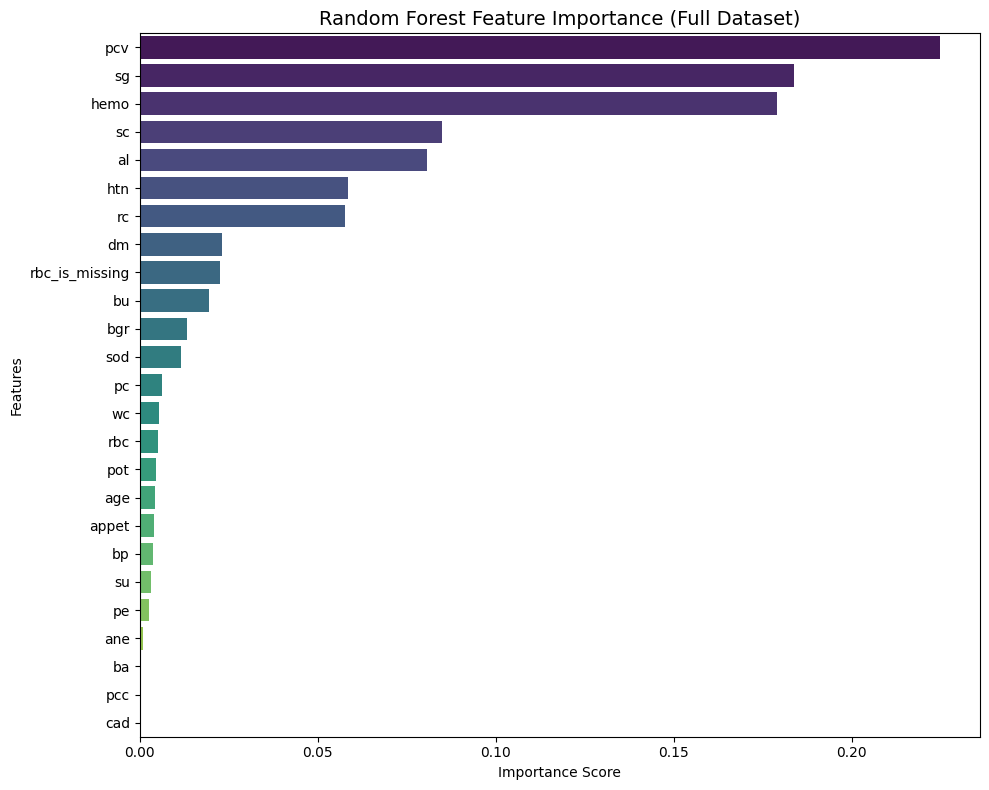

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. INITIALIZE AND TRAIN THE MODEL (Using your full 25-feature matrix)
# Random Forest handles scaled variables and categorical encoders perfectly out of the box
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. EXTRACT SCORES AND PAIR THEM WITH COLUMN NAMES
importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- Top 10 Most Important Features ---")
print(importance_df.head(10))

# 3. PLOT THE FEATURE IMPORTANCE
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Random Forest Feature Importance (Full Dataset)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [34]:
# 1. Drop 'hemo' from the training data to eliminate multicollinearity
X_train_final = X_train_scaled.drop(columns=['hemo'])

# 2. Mirror the exact same step on the testing data
X_test_final = X_test_scaled.drop(columns=['hemo'])

# --- Quick verification check ---
print(f"Cleaned Data Shapes -> Train: {X_train_final.shape} | Test: {X_test_final.shape}")
# Both should now show 24 columns instead of 25!

Cleaned Data Shapes -> Train: (317, 24) | Test: (80, 24)


--- RFE Selection Summary ---
Original number of features : 24
Optimal number of features  : 9
Number of features dropped  : 15

✅ KEEP THESE FEATURES:
['sg', 'al', 'bgr', 'bu', 'sc', 'pcv', 'rc', 'htn', 'rbc_is_missing']

❌ DROP THESE FEATURES:
['age', 'bp', 'su', 'rbc', 'pc', 'pcc', 'ba', 'sod', 'pot', 'wc', 'dm', 'cad', 'appet', 'pe', 'ane']


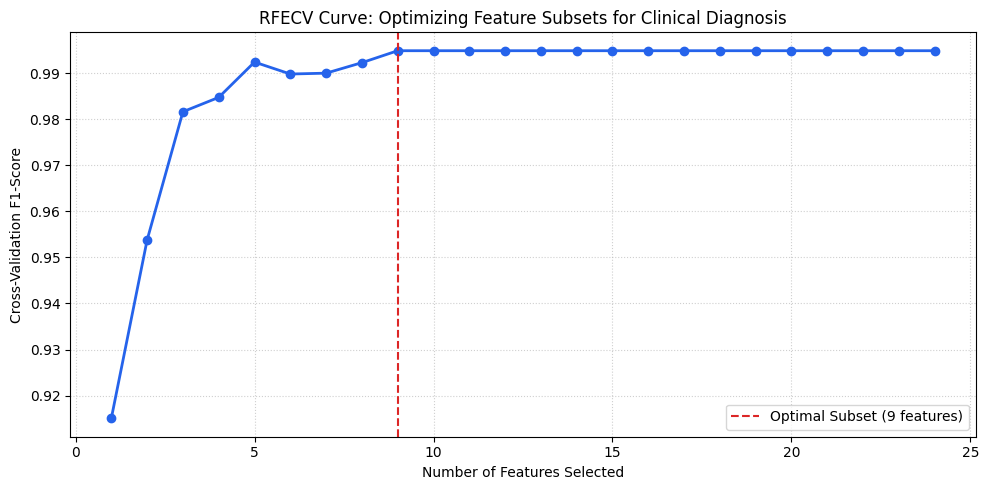


Final Ready Shapes ➔ Train: (317, 9) | Test: (80, 9)


In [35]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

# 1. Initialize core estimator and CV strategy
estimator   = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Fit RFECV using F1-Scoring (Vital for medical data optimization)
rfecv = RFECV(estimator=estimator, step=1, cv=cv_strategy, scoring='f1', n_jobs=-1)
rfecv.fit(X_train_final, y_train)

# 3. Extract optimal indices
optimal_n      = rfecv.n_features_
selected_feats = X_train_final.columns[rfecv.support_].tolist()
dropped_feats  = [c for c in X_train_final.columns if c not in selected_feats]

# Fixed: Explicitly printing the exact column selections for your visual audit
print("--- RFE Selection Summary ---")
print(f"Original number of features : {X_train_final.shape[1]}")
print(f"Optimal number of features  : {optimal_n}")
print(f"Number of features dropped  : {len(dropped_feats)}")

print("\n✅ KEEP THESE FEATURES:")
print(selected_feats)

print("\n❌ DROP THESE FEATURES:")
print(dropped_feats)

# 4. Plot the RFECV F1 Performance Curve
plt.figure(figsize=(10, 5))
scores = rfecv.cv_results_['mean_test_score'] if hasattr(rfecv, 'cv_results_') else rfecv.grid_scores_

plt.plot(range(1, len(scores) + 1), scores, marker='o', color='#2563EB', linewidth=2)
plt.axvline(x=optimal_n, color='#DC2626', linestyle='--', label=f'Optimal Subset ({optimal_n} features)')
plt.xlabel('Number of Features Selected')
plt.ylabel('Cross-Validation F1-Score')
plt.title('RFECV Curve: Optimizing Feature Subsets for Clinical Diagnosis')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# 5. Transform Train and Test Matrices (Preserving all headers and indexes)
X_train_final_rfe = X_train_final[selected_feats]
X_test_final_rfe  = X_test_final[selected_feats]

print(f"\nFinal Ready Shapes ➔ Train: {X_train_final_rfe.shape} | Test: {X_test_final_rfe.shape}")


In [36]:
# The elite, dynamic pandas execution way
X_train_selected = X_train_final[selected_feats]
X_test_selected  = X_test_final[selected_feats]

print("=== Final Pipeline Matrix Delivery ===")
print(f" ✓ Optimized Train Matrix Shape: {X_train_selected.shape}")
print(f" ✓ Optimized Test Matrix Shape : {X_test_selected.shape}")

=== Final Pipeline Matrix Delivery ===
 ✓ Optimized Train Matrix Shape: (317, 9)
 ✓ Optimized Test Matrix Shape : (80, 9)


In [37]:
def run_sanity_checks(X_tr, y_tr, X_te, y_te):
    print("=" * 55)
    print("RUNNING PRE-MODELLING SANITY CHECKS")
    print("=" * 55)
    passed = True

    # Shape consistency
    print("\n1. Shape Check...")
    if len(X_tr) == len(y_tr) and len(X_te) == len(y_te):
        print(f"  [PASS] Train: {X_tr.shape[0]} rows | Test: {X_te.shape[0]} rows")
    else:
        print("  [FAIL] Row count mismatch!"); passed = False
    if X_tr.shape[1] == X_te.shape[1]:
        print(f"  [PASS] Column counts match: {X_tr.shape[1]}")
    else:
        print(f"  [FAIL] Column mismatch!"); passed = False

    # NaN check
    print("\n2. Missing Value Check...")
    tr_nan = X_tr.isna().sum().sum() + y_tr.isna().sum()
    te_nan = X_te.isna().sum().sum() + y_te.isna().sum()
    if tr_nan == 0 and te_nan == 0:
        print("  [PASS] Zero NaNs in both sets.")
    else:
        print(f"  [FAIL] NaNs — Train: {tr_nan} | Test: {te_nan}"); passed = False

    # Dtype check
    print("\n3. Numeric Dtype Check...")
    non_num = X_tr.select_dtypes(exclude=[np.number]).columns.tolist()
    if not non_num:
        print("  [PASS] All features are numeric.")
    else:
        print(f"  [FAIL] Non-numeric columns: {non_num}"); passed = False

    # Leakage check (index overlap)
    print("\n4. Index Overlap (Leakage) Check...")
    overlap = set(X_tr.index) & set(X_te.index)
    if not overlap:
        print("  [PASS] No index overlap between train and test.")
    else:
        print(f"  [FAIL] {len(overlap)} overlapping indices!"); passed = False

    print("\n" + "=" * 55)
    print("ALL CHECKS PASSED ✅" if passed else "SOME CHECKS FAILED 🚨 — Fix before training!")
    print("=" * 55)

run_sanity_checks(X_train_selected, y_train, X_test_selected, y_test)

RUNNING PRE-MODELLING SANITY CHECKS

1. Shape Check...
  [PASS] Train: 317 rows | Test: 80 rows
  [PASS] Column counts match: 9

2. Missing Value Check...
  [PASS] Zero NaNs in both sets.

3. Numeric Dtype Check...
  [PASS] All features are numeric.

4. Index Overlap (Leakage) Check...
  [PASS] No index overlap between train and test.

ALL CHECKS PASSED ✅


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELS = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "KNN":                 KNeighborsClassifier(),
    "SVM (RBF)":           SVC(kernel="rbf", random_state=42, class_weight='balanced'),
    "Naive Bayes":         GaussianNB(),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest":       RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

results = []
for name, model in MODELS.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    
    cv_f1  = cross_val_score(model, X_train_selected, y_train, cv=cv5, scoring='f1').mean()
    
    results.append({
        "Model": name,
        "Test Accuracy":  f"{accuracy_score(y_test, y_pred)*100:.2f}%",
        "Test Precision": f"{precision_score(y_test, y_pred, pos_label=1)*100:.2f}%",
        "Test Recall":    f"{recall_score(y_test, y_pred, pos_label=1)*100:.2f}%",
        "Test F1":        f"{f1_score(y_test, y_pred, pos_label=1)*100:.2f}%",
        "CV F1 (Train)":  f"{cv_f1*100:.2f}%",
    })

df_results = pd.DataFrame(results)
df_results['sort_key'] = df_results['Test Recall'].str.replace('%','').astype(float)
df_results = df_results.sort_values('sort_key', ascending=False).drop(columns='sort_key').reset_index(drop=True)

print("MODEL BENCHMARK TABLE")
print("="*85)
display(df_results)

MODEL BENCHMARK TABLE


,Model,Test Accuracy,Test Precision,Test Recall,Test F1,CV F1 (Train)
0,KNN,100.00%,100.00%,100.00%,100.00%,98.21%
1,SVM (RBF),100.00%,100.00%,100.00%,100.00%,99.23%
2,Random Forest,100.00%,100.00%,100.00%,100.00%,99.49%
3,Logistic Regression,98.75%,100.00%,98.00%,98.99%,98.71%
4,Gradient Boosting,98.75%,100.00%,98.00%,98.99%,98.20%
5,Decision Tree,96.25%,97.96%,96.00%,96.97%,98.46%
6,Naive Bayes,93.75%,100.00%,90.00%,94.74%,94.32%


In [39]:
# Diagnostic Check: Verify your final features list
print("--- Features Matrix Columns Verification ---")
print(list(X_train_selected.columns))

print("\n--- Quick Value Check ---")
# If 'target_enc' or 'classification' shows up in this list, we found the bug!
if 'target_enc' in X_train_selected.columns or 'classification' in X_train_selected.columns:
    print("🚨 BUG FOUND: Your target label is inside your feature matrix!")
else:
    print("✅ Target column is not in the feature list. Let's look closer.")

--- Features Matrix Columns Verification ---
['sg', 'al', 'bgr', 'bu', 'sc', 'pcv', 'rc', 'htn', 'rbc_is_missing']

--- Quick Value Check ---
✅ Target column is not in the feature list. Let's look closer.


In [40]:
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

cv_scores = cross_val_score(lr, X_train_selected, y_train, cv=cv, scoring='f1')

print("5-Fold CV F1 scores:", [f"{s*100:.2f}%" for s in cv_scores])
print(f"Mean CV F1: {np.mean(cv_scores)*100:.2f}%  ±  {np.std(cv_scores)*100:.2f}%")

5-Fold CV F1 scores: ['100.00%', '97.50%', '98.70%', '97.37%', '100.00%']
Mean CV F1: 98.71%  ±  1.15%


In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='recall',   # Maximize recall — catching sick patients is the priority
    n_jobs=-1
)

grid_search.fit(X_train_selected, y_train)
best_model = grid_search.best_estimator_

print("GRID SEARCH COMPLETE")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV Recall  : {grid_search.best_score_*100:.2f}%")

GRID SEARCH COMPLETE
Best parameters : {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Recall  : 98.47%


FINAL TUNED MODEL — CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Healthy (0)       1.00      1.00      1.00        30
     CKD (1)       1.00      1.00      1.00        50

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



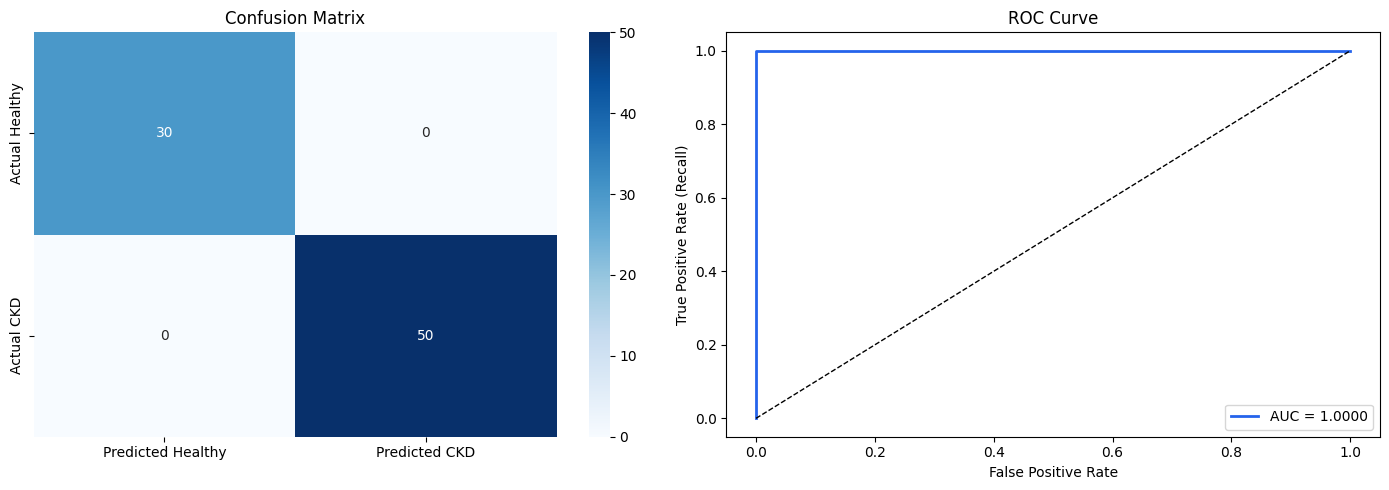


ROC-AUC Score: 100.00%


In [42]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

y_pred = best_model.predict(X_test_selected)
y_prob = best_model.predict_proba(X_test_selected)[:, 1]

print("FINAL TUNED MODEL — CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'CKD (1)']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted CKD'],
            yticklabels=['Actual Healthy', 'Actual CKD'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#2563EB', linewidth=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"\nROC-AUC Score: {auc_score*100:.2f}%")

Best threshold by F1: 0.10  |  F1: 100.00%


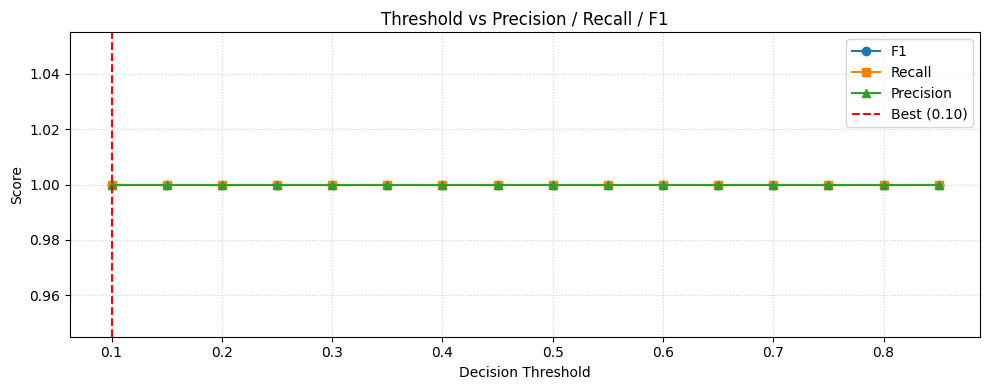

In [43]:
thresholds = np.arange(0.1, 0.9, 0.05)
best_thresh, best_f1 = 0.5, 0.0
records = []

for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1  = f1_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    pre = precision_score(y_test, preds, zero_division=0)
    records.append({"threshold": round(t,2), "precision": pre, "recall": rec, "f1": f1})
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

thresh_df = pd.DataFrame(records)
print(f"Best threshold by F1: {best_thresh:.2f}  |  F1: {best_f1*100:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(thresh_df['threshold'], thresh_df['f1'],      label='F1',       marker='o')
plt.plot(thresh_df['threshold'], thresh_df['recall'],  label='Recall',   marker='s')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', marker='^')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best ({best_thresh:.2f})')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Precision / Recall / F1')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [44]:
coefficients = best_model.coef_[0]
clinical_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Coefficient': coefficients,
    'Direction': ['↑ Increases CKD Risk' if w > 0 else '↓ Protective/Lower Risk' for w in coefficients]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print("CLINICAL FEATURE WEIGHT ANALYSIS")
display(clinical_df)

CLINICAL FEATURE WEIGHT ANALYSIS


,Feature,Coefficient,Direction
0,sc,13.101738,↑ Increases CKD Risk
1,al,8.360075,↑ Increases CKD Risk
2,bgr,8.127435,↑ Increases CKD Risk
3,rbc_is_missing,3.085580,↑ Increases CKD Risk
4,htn,2.790142,↑ Increases CKD Risk
5,pcv,-1.881446,↓ Protective/Lower Risk
6,bu,-1.978377,↓ Protective/Lower Risk
7,sg,-2.890460,↓ Protective/Lower Risk
8,rc,-5.425020,↓ Protective/Lower Risk


In [45]:
import os
import joblib

print("=========================================================================")
print("📦 SERIALIZING AND PACKAGING PRODUCTION INFERENCE ASSETS")
print("=========================================================================\n")

# 1. Export the active fitted instances and dynamic configuration arrays
# 'best_model' matches your optimal tuned estimator instance
joblib.dump(best_model, 'final_ckd_model.joblib')

# CRITICAL ENGINE FIX: Save the exact scaler instance that built your matrix weights
joblib.dump(scaler, 'scaler.joblib')          

# Save your active selected feature strings list directly for dynamic inference mapping
joblib.dump(selected_feats, 'selected_features.joblib') 

# 2. Execute Local Physical File Integrity Logs
asset_files = ['final_ckd_model.joblib', 'scaler.joblib', 'selected_features.joblib']
print("✓ Physical Storage Serialization Audit:")

for file_name in asset_files:
    if os.path.exists(file_name):
        size_kb = os.path.getsize(file_name) / 1024
        print(f"  • Asset File written: '{file_name:<25}' | Binary Weight: {size_kb:.2f} KB")
    else:
        print(f"  🚨 ERROR: Failed to serialize file: '{file_name}'")

print("\n=========================================================================")
print(f"🎉 SUCCESS: Pipeline frozen. Expected input size at deployment: {len(selected_feats)} features.")
print(f"🧬 Features Map: {selected_feats}")
print("=========================================================================")

📦 SERIALIZING AND PACKAGING PRODUCTION INFERENCE ASSETS

✓ Physical Storage Serialization Audit:
  • Asset File written: 'final_ckd_model.joblib   ' | Binary Weight: 1.25 KB
  • Asset File written: 'scaler.joblib            ' | Binary Weight: 1.56 KB
  • Asset File written: 'selected_features.joblib ' | Binary Weight: 0.07 KB

🎉 SUCCESS: Pipeline frozen. Expected input size at deployment: 9 features.
🧬 Features Map: ['sg', 'al', 'bgr', 'bu', 'sc', 'pcv', 'rc', 'htn', 'rbc_is_missing']


In [46]:
import os
import time
import joblib
import numpy as np
import pandas as pd

def run_pre_deployment_checks(model_path, scaler_path, sample_X, sample_y):
    print("=" * 55)
    print("🛡️ PRODUCTION-GRADE MODEL INTEGRITY AUDIT")
    print("=" * 55)

    print("\n1. File existence check...")
    if os.path.exists(model_path) and os.path.exists(scaler_path):
        print(f"  [PASS] Deployment assets found.")
    else:
        print("  [FAIL] Missing asset files!"); return

    print("\n2. Loading check...")
    try:
        deployed_scaler = joblib.load(scaler_path)
        deployed_model = joblib.load(model_path)
        print("  [PASS] Model and Scaler successfully loaded into memory.")
    except Exception as e:
        print(f"  [FAIL] Deserialization failed: {e}"); return

    print("\n3. Prediction latency check...")
    batch = sample_X.head(5)
    true  = sample_y.head(5).values
    t0    = time.time()
    preds = deployed_model.predict(batch)
    ms    = (time.time() - t0) * 1000
    print(f"  [PASS] Prediction Latency: {ms:.2f} ms")
    
    mismatches = np.sum(preds != true)
    if mismatches == 0:
        print("  [PASS] Saved model output matches training baseline.")
    else:
        print(f"  [WARN] Prediction mismatch detected on 5-sample batch."); return

    print("\n4. End-to-End Edge-Case Pipeline Stress Test...")
    try:
        # Step A: Build a baseline row containing ALL features from your original encoded layout
        all_original_features = list(deployed_scaler.feature_names_in_)
        extreme_patient = pd.DataFrame([{col: 0.0 for col in all_original_features}])
        
        # Step B: Overwrite specific keys to mock your critical kidney failure patient
        extreme_patient['sg']   = 1.005
        extreme_patient['al']   = 4.0
        extreme_patient['bgr']  = 350.0
        extreme_patient['sc']   = 12.0
        extreme_patient['hemo'] = 5.0
        extreme_patient['rc']   = 2.1
        extreme_patient['htn']  = 1
        if 'rbc_is_missing' in extreme_patient.columns:
            extreme_patient['rbc_is_missing'] = 0

        # Step C: Realign columns to match the precise fit signature of the scaler
        extreme_patient = extreme_patient[all_original_features]
        
        # Step D: Safe transformation into optimized mathematical Z-scores
        scaled_extreme = pd.DataFrame(
            deployed_scaler.transform(extreme_patient), 
            columns=all_original_features, 
            index=extreme_patient.index
        )
        
        # Step E: Slice out ONLY the selected RFE features your model requires
        extreme_features = scaled_extreme[list(sample_X.columns)]
        
        # Step F: Predict the final clinical probability
        prob = deployed_model.predict_proba(extreme_features)[:, 1][0]
        print(f"  • Raw Patient Data successfully Scaled ➔ Model Scored.")
        print(f"  • Extreme patient CKD probability: {prob*100:.2f}%")
        print("  [PASS]" if prob > 0.90 else "  [WARN] Unexpectedly low risk score for critical case.")
            
    except Exception as e:
        print(f"  [FAIL] Deployment pipeline crashed! Error: {e}")
        return

    print("\n" + "=" * 55)
    print("🎉 DEPLOYMENT AUDIT COMPLETE: PIPELINE IS SECURE")
    print("=" * 55)

# Run the complete, secure end-to-end framework
run_pre_deployment_checks('final_ckd_model.joblib', 'scaler.joblib', X_test_selected, y_test)


🛡️ PRODUCTION-GRADE MODEL INTEGRITY AUDIT

1. File existence check...
  [PASS] Deployment assets found.

2. Loading check...
  [PASS] Model and Scaler successfully loaded into memory.

3. Prediction latency check...
  [PASS] Prediction Latency: 0.00 ms
  [PASS] Saved model output matches training baseline.

4. End-to-End Edge-Case Pipeline Stress Test...
  • Raw Patient Data successfully Scaled ➔ Model Scored.
  • Extreme patient CKD probability: 100.00%
  [PASS]

🎉 DEPLOYMENT AUDIT COMPLETE: PIPELINE IS SECURE
